### 1. Conectar con Google Drive e Importar Librerías
Ejecuta la siguiente celda para dar acceso a Colab a tus archivos de Drive e importar `pandas` y `numpy`.

In [2]:
import os
import numpy as np
import pandas as pd
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Configurar la Ruta y Listar Archivos
Por defecto, al montar Google Drive, tu unidad principal se encuentra en `/content/drive/My Drive/`.

IMPORTANTE => Hacer un acceso directo de la carpeta Datos a tu unidad para que el programa pueda leer los archivos.


In [3]:
import os
import pandas as pd

def buscar_ruta_carpeta(nombre_carpeta_buscar, ruta_principal = '/content/drive/My Drive/Datos'):
    # Esta función busca de manera insensible a mayúsculas/minúsculas
    nombre_buscar_lower = nombre_carpeta_buscar.lower()

    for raiz, directorios, archivos in os.walk(ruta_principal):
        for directorio in directorios:
            if directorio.lower() == nombre_buscar_lower:
                return os.path.join(raiz, directorio)
    return None

nombre_carpeta = 'datos vacas en establo marzo_junio_2025'
ruta_final = buscar_ruta_carpeta(nombre_carpeta)

if ruta_final:
    print(f"¡Éxito! Carpeta detectada en: {ruta_final}\n")
    archivos = [f for f in os.listdir(ruta_final) if f.endswith('.csv')]
    print(f"Se encontraron {len(archivos)} archivos de datos relevantes:")
    for i, archivo in enumerate(archivos[:10], 1):
        print(f"{i}. {archivo}")
    if len(archivos) > 10:
        print("... y más.")
else:
    print("Aún no se detectó el acceso directo. Por favor verifica que esté en 'Mi Unidad/Datos/datos vacas en establo marzo_junio_2025' y vuelve a ejecutar esta celda.")

¡Éxito! Carpeta detectada en: /content/drive/My Drive/Datos/DATOS vacas en establo marzo_junio_2025

Se encontraron 37 archivos de datos relevantes:
1. 6232.csv
2. 2076.csv
3. 6003.csv
4. 8775.csv
5. reporte_180725.csv
6. 1613.csv
7. 6211.csv
8. 8729.csv
9. 1624.csv
10. inventario_total_180725.csv
... y más.


### 4. Lectura, Consolidación y Ordenamiento de los Datos
El siguiente código leerá todos los archivos de datos encontrados en la carpeta, omitirá la primera fila de datos de cada uno (manteniendo la estructura de cabeceras), combinará toda la información en un solo DataFrame de Pandas y finalmente ordenará los registros por la columna **'Hora de inicio'**.

In [4]:
import os
import pandas as pd

lista_df = []

print("Iniciando la lectura de archivos...")
for archivo in archivos:
    # Omitir archivos que no empiecen con un número
    if not archivo[0].isdigit():
        continue

    ruta_archivo = os.path.join(ruta_final, archivo)

    try:
        # Leer según el tipo de extensión del archivo
        # skiprows=1 se usa para saltarse la primera línea de datos físicos del archivo.
        df_temp = pd.read_csv(ruta_archivo, skiprows=1)

        # Añadir una columna para saber de qué archivo proviene cada registro
        df_temp['Origen_Archivo'] = archivo
        lista_df.append(df_temp)

    except Exception as e:
        print(f"No se pudo procesar el archivo {archivo}. Error: {e}")

print(f"\nArchivos procesados correctamente: {len(lista_df)}")
if lista_df:
    print(f"Columnas que deberían de tener: {len(lista_df[0].columns)}")
    acum = {'sum': 0, 'max': 0, 'min': 9999}
    for df in (lista_df):
      acum["sum"] += len(df.columns)
      acum["max"] = max(acum["max"], len(df.columns))
      acum["min"] = min(acum["min"], len(df.columns))

    print(f"Promedio de categorías: {acum['sum'] / len(lista_df)}")
    print(f"Máximo de categorías:  {acum['max']}")
    print(f"Mínimo de categorías: {acum['min']}")

Iniciando la lectura de archivos...

Archivos procesados correctamente: 34
Columnas que deberían de tener: 36
Promedio de categorías: 36.0
Máximo de categorías:  36
Mínimo de categorías: 36


In [5]:
# Concatenar todos los dataframes en uno solo
if lista_df:
    df_consolidado = pd.concat(lista_df, ignore_index=True)
    print(f"\n¡Unión completada! Total de registros cargados: {len(df_consolidado)}")

    # Intentar ordenar por 'Hora de inicio' si la columna existe
    columna_orden = 'Hora de inicio'
    if columna_orden in df_consolidado.columns:
        # Convertimos a tipo datetime para ordenar cronológicamente de forma correcta
        df_consolidado[columna_orden] = pd.to_datetime(df_consolidado[columna_orden], errors='coerce')
        df_consolidado = df_consolidado.sort_values(by=columna_orden).reset_index(drop=True)
        print(f"Datos ordenados correctamente por '{columna_orden}'.")
    else:
        print(f"\nAdvertencia: No se encontró la columna '{columna_orden}' para ordenar. Las columnas disponibles son:")
        print(list(df_consolidado.columns))

    # Mostrar una vista previa del DataFrame final
    display(df_consolidado.head())
else:
    print("No se cargó ningún dato. Verifica que los archivos no estén vacíos o corruptos.")


¡Unión completada! Total de registros cargados: 7249
Datos ordenados correctamente por 'Hora de inicio'.


,Hora de inicio,Acción,Duración (mm:ss),Producción (kg),Número de ordeño,RCS (* 1000 células / ml),Patada,Incompleto,Pezones no encontrados,Ubre,...,Razón de la desviación,DI.3,DD.3,TI.3,TD.3,DI.4,DD.4,TI.4,TD.4,Origen_Archivo
0,2025-01-03 01:06:00,Ordeño,08:29,20.64,1.0,NaN,NaN,NaN,NaN,0.0,...,NaN,1.68,1.62,1.50,1.86,4.62,3.88,6.17,5.97,6194.csv
1,2025-01-03 01:37:00,Ordeño,07:55,23.08,1.0,NaN,NaN,NaN,NaN,0.0,...,NaN,1.80,2.22,2.82,2.10,2.58,3.29,8.63,8.58,6238.csv
2,2025-01-03 01:38:00,Ordeño,09:04,3.73,1.0,NaN,DI,"TI,TD","TI,TD",0.0,...,NaN,1.26,0.96,0.00,0.00,1.87,1.86,0.00,0.00,2078.csv
3,2025-01-03 02:02:00,Ordeño,05:34,14.40,1.0,NaN,TD,NaN,NaN,0.0,...,NaN,1.68,1.68,2.10,2.40,2.93,3.42,3.51,4.54,2076.csv
4,2025-01-03 02:18:00,Ordeño,08:13,11.14,1.0,NaN,NaN,NaN,NaN,0.0,...,NaN,1.56,1.50,1.20,1.92,3.37,2.76,0.96,4.05,1233.csv


### 5. Procesamiento de Nuevos Datos Históricos (Clasificación por tipo de archivo)
En esta sección clasificamos los archivos `.xlsx` de la carpeta `Datos vacas historico hasta enero 2026/TEC-UAQ-UNAM` en diferentes DataFrames según su prefijo.

In [6]:
import os
import pandas as pd

# 1. Definir y buscar la nueva carpeta de datos históricos
nombre_carpeta = 'TEC-UAQ-UNAM'
ruta_historico = buscar_ruta_carpeta(nombre_carpeta, ruta_principal='/content/drive/My Drive/Datos/Datos vacas historico hasta enero 2026')

def read_detailed_data():
  if ruta_historico:
      print(f"¡Éxito! Carpeta detectada en: {ruta_historico}\n")

      # Listar todos los archivos Excel (.xlsx)
      todos_archivos = [f for f in os.listdir(ruta_historico) if f.endswith('.xlsx') or f.endswith('.xls')]
      print(f"Se encontraron {len(todos_archivos)} archivos Excel en total.")

      # Inicializar listas para clasificar los DataFrames
      lista_concentrado = []
      lista_produccion_leche = []

      # 2. Iterar y clasificar los archivos
      for archivo in todos_archivos:
          ruta_archivo = os.path.join(ruta_historico, archivo)

          # Extraer el ID o número del animal del nombre del archivo como referencia
          # Ej: 'Concentrado consumido 216.xlsx' -> extrae '216'
          id_vaca = "".join(filter(str.isdigit, archivo))

          try:
              if archivo.lower().startswith('concentrado consumido'):
                  df_temp = pd.read_excel(ruta_archivo)
                  df_temp['Origen_Archivo'] = archivo
                  df_temp['ID_Vaca'] = id_vaca if id_vaca else 'Desconocido'
                  lista_concentrado.append(df_temp)

              else:
                  df_temp = pd.read_excel(ruta_archivo, skiprows=1)
                  df_temp['Origen_Archivo'] = archivo
                  df_temp['ID_Vaca'] = id_vaca if id_vaca else 'Desconocido'
                  lista_produccion_leche.append(df_temp)

          except Exception as e:
              print(f"Error al procesar el archivo {archivo}: {e}")

      print(f"\nClasificación completada:")
      print(f"- Archivos de 'Concentrado consumido' procesados: {len(lista_concentrado)}")
      print(f"- Archivos de 'Producciones de leche por sesión' procesados: {len(lista_produccion_leche)}")

      return lista_concentrado, lista_produccion_leche

  else:
      print(f"No se encontró la carpeta '{nombre_carpeta}'. Asegúrate de que esté dentro de 'Mi Unidad/Datos/'.")


### 6. Consolidación de los nuevos DataFrames
Creamos los DataFrames integrados para cada tipo de dato y visualizamos su estructura.

In [7]:
def show_details(lista_concentrado, lista_produccion_leche):
  # Consolidar Concentrado Consumido
  if lista_concentrado:
      concentradoConsumido = pd.concat(lista_concentrado, ignore_index=True)
      print(f"¡DataFrame 'concentradoConsumido' creado exitosamente!")
      print(f"Total de filas: {len(concentradoConsumido)} | Columnas: {list(concentradoConsumido.columns)}\n")
      display(concentradoConsumido.head())
  else:
      print("No se encontraron archivos de Concentrado Consumido.")

  print("-" * 80)

  # Consolidar Producción de Leche por Sesión
  if lista_produccion_leche:
      produccionesLecheSesion = pd.concat(lista_produccion_leche, ignore_index=True)
      print(f"¡DataFrame 'produccionesLecheSesion' creado exitosamente!")
      print(f"Total de filas: {len(produccionesLecheSesion)} | Columnas: {list(produccionesLecheSesion.columns)}\n")
      display(produccionesLecheSesion.head())
  else:
      print("No se encontraron archivos de Producción de Leche.")


In [8]:
lista_concentrado, lista_produccion_leche = read_detailed_data()

show_details(lista_concentrado, lista_produccion_leche)

¡Éxito! Carpeta detectada en: /content/drive/My Drive/Datos/Datos vacas historico hasta enero 2026/TEC-UAQ-UNAM

Se encontraron 404 archivos Excel en total.

Clasificación completada:
- Archivos de 'Concentrado consumido' procesados: 203
- Archivos de 'Producciones de leche por sesión' procesados: 201
¡DataFrame 'concentradoConsumido' creado exitosamente!
Total de filas: 130315 | Columnas: ['Alimento', 'Hora evento', 'Consumido', 'Consumido Mat. Seca', 'Origen_Archivo', 'ID_Vaca']



,Alimento,Hora evento,Consumido,Consumido Mat. Seca,Origen_Archivo,ID_Vaca
0,Feed1,2026-01-28 06:00:00,0.289,0.289,Concentrado consumido 6003.xlsx,6003
1,Feed1,2026-01-27 23:00:00,0.352,0.352,Concentrado consumido 6003.xlsx,6003
2,Feed1,2026-01-27 16:00:00,0.438,0.438,Concentrado consumido 6003.xlsx,6003
3,Feed1,2026-01-27 07:00:00,0.841,0.841,Concentrado consumido 6003.xlsx,6003
4,Feed1,2026-01-26 15:00:00,0.201,0.201,Concentrado consumido 6003.xlsx,6003


--------------------------------------------------------------------------------
¡DataFrame 'produccionesLecheSesion' creado exitosamente!
Total de filas: 278968 | Columnas: ['Hora de inicio', 'Número de ordeño', 'Duración (mm:ss)', 'Producción (kg)', 'RCS (* 1000 células / ml)', 'Intervalo de ordeño (hh:mm)', 'DI', 'DD', 'TI', 'TD', 'Ubre', 'Pezón', 'DI.1', 'DD.1', 'TI.1', 'TD.1', 'DI.2', 'DD.2', 'TI.2', 'TD.2', 'DI.3', 'DD.3', 'TI.3', 'TD.3', 'DI.4', 'DD.4', 'TI.4', 'TD.4', 'Ubre.1', 'DI.5', 'DD.5', 'TI.5', 'TD.5', 'Destino Leche', 'Razón de la desviación', 'Programa de lavado', 'MS', 'Usuario', 'Patada', 'Incompleto', 'Pezones no encontrados', 'MDI', 'Origen_Archivo', 'ID_Vaca']



,Hora de inicio,Número de ordeño,Duración (mm:ss),Producción (kg),RCS (* 1000 células / ml),Intervalo de ordeño (hh:mm),DI,DD,TI,TD,...,Razón de la desviación,Programa de lavado,MS,Usuario,Patada,Incompleto,Pezones no encontrados,MDI,Origen_Archivo,ID_Vaca
0,2026-01-28 06:29:45,1,00:06:52,12.38,NaN,06:44:23,1.12,5.35,2.01,3.90,...,NaN,NaN,VMS 3,NaN,NaN,NaN,NaN,1.490764,Producciones de leche por sesión 6003.xlsx,6003
1,2026-01-27 23:38:32,3,00:06:50,11.43,NaN,07:01:21,3.10,4.07,1.66,2.60,...,NaN,NaN,VMS 3,NaN,NaN,NaN,NaN,1.220610,Producciones de leche por sesión 6003.xlsx,6003
2,2026-01-27 16:32:34,2,00:04:37,8.86,NaN,08:42:29,1.02,3.07,1.82,2.95,...,NaN,NaN,VMS 3,NaN,NaN,NaN,NaN,1.197863,Producciones de leche por sesión 6003.xlsx,6003
3,2026-01-27 07:45:12,1,00:04:53,11.96,NaN,15:48:08,1.23,2.11,3.32,5.30,...,NaN,NaN,VMS 3,NaN,NaN,DD,NaN,1.472224,Producciones de leche por sesión 6003.xlsx,6003
4,2026-01-26 15:52:13,2,00:04:51,11.54,NaN,09:41:47,0.99,4.37,2.40,3.78,...,NaN,NaN,VMS 3,NaN,NaN,NaN,NaN,1.180405,Producciones de leche por sesión 6003.xlsx,6003


## 7. Describir los datos

Dentro de esta área se describe el formato, volumen y la calidad de los datos.Trabajamos principalmente con los registros del robot de ordeña por sesión, debido a que es la que contiene la hora de inicio, duración del ordeño y el robot, necesarios para estudiar la formación de las colas.


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,5)

# show_details() solo muestra los DataFrames aqui los guardamos para trabajar con ellos
concentradoConsumido = pd.concat(lista_concentrado, ignore_index=True)
prodLecheSesion = pd.concat(lista_produccion_leche, ignore_index = True)

df = prodLecheSesion.copy()
print(f"Registros: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"Memoria utilizada: {df.memory_usage(deep=True).sum()/ 1024**2:.1f} MB")

Registros: 278,968 | Columnas: 44
Memoria utilizada: 237.8 MB


## 8. Conversion de tipos

Convertimos Hora de inicio a fecha y hora, y la duracion e intervalo de ordeño a minutos con la funcion a_min. No solo eso, sino que extraemos fecha, hora, dia de la semana y mes para analizar patrones temporales en la formacion de colas.

In [27]:
def a_min(serie):
  """ Convierte duraciones tipo hh:mm:ss, mm:ss u objetos time a minutos(floats)"""
  s = serie.astype(str).str.strip()
  s = s.where(~s.isin(["nan", "NaT", "None", ""]))

  #En el caso de que venga mm:ss se agrega la hora en 0
  s = s.where(s.str.count(":") != 1, "00:" +s)

  #Los objetos daytime se quedan solo con la hora
  s = s.str.split(" ").str[-1]
  return pd.to_timedelta(s, errors= "coerce").dt.total_seconds() / 60

df["Hora de inicio"] = pd.to_datetime(df["Hora de inicio"], errors="coerce")
df["duracion_min"] = a_min(df["Duración (mm:ss)"])
df["intervalo_min"] = a_min(df['Intervalo de ordeño (hh:mm)'])

df["fecha"] = df["Hora de inicio"].dt.date
df["hora"] = df["Hora de inicio"].dt.hour
df["dia_semana"] = df["Hora de inicio"].dt.day_of_week
df["mes"] = df["Hora de inicio"].dt.to_period("M")

print("Duraciones no convertibles:", df["duracion_min"].isna().sum())
print("Intervalos no convertibles:", df["intervalo_min"].isna().sum())
df[["Hora de inicio", "Duración (mm:ss)", "duracion_min", "Intervalo de ordeño (hh:mm)", "intervalo_min"]].head()

Duraciones no convertibles: 0
Intervalos no convertibles: 0


,Hora de inicio,Duración (mm:ss),duracion_min,Intervalo de ordeño (hh:mm),intervalo_min
0,2026-01-28 06:29:45,00:06:52,6.866667,06:44:23,404.383333
1,2026-01-27 23:38:32,00:06:50,6.833333,07:01:21,421.350000
2,2026-01-27 16:32:34,00:04:37,4.616667,08:42:29,522.483333
3,2026-01-27 07:45:12,00:04:53,4.883333,15:48:08,948.133333
4,2026-01-26 15:52:13,00:04:51,4.850000,09:41:47,581.783333


## 9. Cobertura de los datos (tiempos, vacas y robots)

Dentro de esta area se revisa el periodo que cubren los registros, el numero de vacas, robots distintos y como se distribuyen en los ordeños por robot y mes. Esto detecta huecos en el tiempo o robots con pocos datos antes del analisis

In [28]:
inicio, fin = df["Hora de inicio"].min(), df["Hora de inicio"].max()
print(f"Periodo: {inicio:%Y-%m-%d} a {fin:%Y-%m-%d}  ({(fin - inicio).days} días)")
print(f"Vacas distintas: {df['ID_Vaca'].nunique()}")
print(f"Robots (MS) distintos: {df['MS'].nunique()} -> {sorted(df['MS'].dropna().unique())}")

print("\nRegistros por robot:")
display(df["MS"].value_counts(dropna=False).to_frame("registros"))

print("Registros por mes:")
display(df.groupby("mes").size().to_frame("registros").T)

Periodo: 2022-07-13 a 2026-01-28  (1295 días)
Vacas distintas: 201
Robots (MS) distintos: 3 -> ['VMS 1', 'VMS 2', 'VMS 3']

Registros por robot:


,registros
MS,
VMS 1,96982
VMS 2,91460
VMS 3,90524
NaN,2


Registros por mes:


mes,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,...,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01
registros,1406,2530,2667,2867,2855,2979,3075,3081,3716,3764,...,8629,9715,9634,9867,10153,10400,10616,11088,11559,10414


## 10. Diccionario de datos y calidad (tipos, nulos y valores únicos)

Generamos un resumen de cada columna con su tipo de dato, cantidad de valores nulos y unicos, y un ejemplo. Ayuda a identificar columnas casi vacias o poco utiles para el analisis de colas.

In [29]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "no_nulos": df.notna().sum(),
    "% nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(),
    "ejemplo": df.apply(lambda c: c.dropna().iloc[0] if c.notna().any() else None),
}).sort_values("% nulos", ascending=False)

pd.set_option("display.max_rows", 100)
resumen

,tipo,no_nulos,% nulos,valores_unicos,ejemplo
RCS (* 1000 células / ml),float64,0,100.00,0,None
Usuario,object,2,100.00,1,DelproCliente
Razón de la desviación,object,1542,99.45,2,Sangre por pezón por encima del umbral
Programa de lavado,object,15695,94.37,1,Local Aclarado
Pezón,object,26161,90.62,15,DI
Pezones no encontrados,object,32936,88.19,15,TD
Incompleto,object,33405,88.03,15,DD
Patada,object,44889,83.91,15,"DD,TD"
MDI,float64,257206,7.80,175520,1.490764
TD.1,float64,267968,3.94,87,1.86


In [30]:
# Columnas casi vacías (> 90 % nulos): candidatas a descartar en la preparación de datos
casi_vacias = resumen[resumen["% nulos"] > 90].index.tolist()
print(f"Columnas con más de 90 % de nulos ({len(casi_vacias)}):")
print(casi_vacias)

# Registros duplicados (misma vaca, mismo robot, misma hora de inicio)
dups = df.duplicated(subset=["ID_Vaca", "MS", "Hora de inicio"]).sum()
print(f"\nRegistros duplicados (vaca + robot + hora de inicio): {dups:,}")
print(f"Registros sin fecha válida: {df['Hora de inicio'].isna().sum():,}")

Columnas con más de 90 % de nulos (5):
['RCS (* 1000 células / ml)', 'Usuario', 'Razón de la desviación', 'Programa de lavado', 'Pezón']

Registros duplicados (vaca + robot + hora de inicio): 0
Registros sin fecha válida: 0


## 11. Estadistica descriptiva de las variables numericas clave

Calculamos estadisticas basicas (media, desviacion, minimos, maximos y percentiles) de la duracion, intervalo, produccion, numero de ordeño y MDI. Nos ayuda a verificar si existen rangos atipicos que puedan afectar el analisis.

In [31]:
vars_clave = ["duracion_min", "intervalo_min", "Producción (kg)", "Número de ordeño", "MDI"]
vars_clave = [c for c in vars_clave if c in df.columns]
df[vars_clave].describe(percentiles=[.05, .25, .5, .75, .95]).T.round(2)

,count,mean,std,min,5%,25%,50%,75%,95%,max
duracion_min,278968.0,8.10,2.58,0.38,4.90,6.25,7.60,9.40,13.07,55.80
intervalo_min,278968.0,574.25,209.66,0.00,295.94,433.52,540.83,684.43,966.98,1439.95
Producción (kg),278968.0,14.82,5.34,0.00,7.06,11.07,14.30,18.10,24.34,78.17
Número de ordeño,278968.0,1.84,0.85,1.00,1.00,1.00,2.00,2.00,3.00,6.00
MDI,257206.0,1.23,0.42,0.71,1.02,1.06,1.10,1.18,1.93,15.36


In [32]:
# Variables categóricas
for col in ["Destino Leche", "Razón de la desviación", "Patada", "Incompleto", "Pezones no encontrados", "Usuario"]:
    if col in df.columns:
        print(f"--- {col} ---")
        print(df[col].value_counts(dropna=False).head(8).to_string(), "\n")

--- Destino Leche ---
Destino Leche
Tanque      263224
Drenaje      10377
Divert 3      5360
Divert 2         6
Divert 1         1 

--- Razón de la desviación ---
Razón de la desviación
NaN                                       277426
Sangre por pezón por encima del umbral      1498
Separada manualmente                          44 

--- Patada ---
Patada
NaN      234079
TD        14548
DI        11430
TI         5686
DD         4930
TI,TD      2065
DI,DD      1386
DI,TD      1228 

--- Incompleto ---
Incompleto
NaN      245563
TD        10380
TI         9391
DI         3015
DD         3001
TI,TD      2128
DI,TI       852
Todos       781 

--- Pezones no encontrados ---
Pezones no encontrados
NaN      246032
TD        11348
TI         9663
DI         3151
DD         3084
TI,TD      2054
DI,TI       683
DD,TD       416 

--- Usuario ---
Usuario
NaN              278966
DelproCliente         2 



In [33]:
# Descripción breve de las otras fuentes de datos
print("concentradoConsumido:", concentradoConsumido.shape)
display(concentradoConsumido.describe(include="all").T)

print("df_consolidado (marzo-junio 2025):", df_consolidado.shape)
print("Columnas:", list(df_consolidado.columns))

concentradoConsumido: (130315, 6)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Alimento,130315,1,Feed1,130315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hora evento,130315,NaN,NaN,NaN,2025-08-08 16:39:48.655182080,2025-01-28 00:00:00,2025-05-11 11:00:00,2025-08-13 17:00:00,2025-11-09 10:00:00,2026-01-28 11:00:00,NaN
Consumido,130315.0,NaN,NaN,NaN,1.10338,0.0,0.667,1.086,1.495,4.715,0.582901
Consumido Mat. Seca,130315.0,NaN,NaN,NaN,1.10338,0.0,0.667,1.086,1.495,4.715,0.582901
Origen_Archivo,130315,203,Concentrado consumido 6122.xlsx,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ID_Vaca,130315,203,6122,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN


df_consolidado (marzo-junio 2025): (7249, 36)
Columnas: ['Hora de inicio', 'Acción', 'Duración (mm:ss)', 'Producción (kg)', 'Número de ordeño', 'RCS (* 1000 células / ml)', 'Patada', 'Incompleto', 'Pezones no encontrados', 'Ubre', 'Pezón', 'DI', 'DD', 'TI', 'TD', 'DI.1', 'DD.1', 'TI.1', 'TD.1', 'DI.2', 'DD.2', 'TI.2', 'TD.2', 'EO/PO', 'Usuario', 'Destino Leche', 'Razón de la desviación', 'DI.3', 'DD.3', 'TI.3', 'TD.3', 'DI.4', 'DD.4', 'TI.4', 'TD.4', 'Origen_Archivo']


## 12. Explorar los datos

En la primera seccion graficamos el numero de ordeños por hora del dia y por dia de la semana.

En la segunda seccion graficamos el histograma de la duracion de ordeño, el intervalo entre ordeños de la misma vaca y la produccion por ordeño.

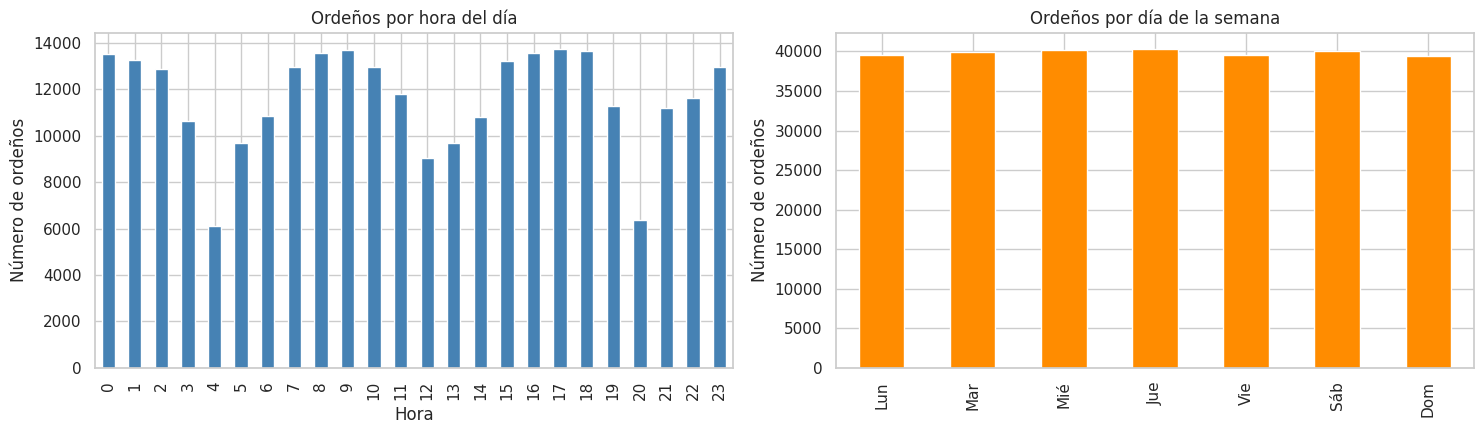

In [34]:
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
df.groupby("hora").size().plot.bar(ax=axes[0], color="steelblue")
axes[0].set(title="Ordeños por hora del día", xlabel="Hora", ylabel="Número de ordeños")

df.groupby("dia_semana").size().rename(index=dict(enumerate(dias))).plot.bar(ax=axes[1], color="darkorange")
axes[1].set(title="Ordeños por día de la semana", xlabel="", ylabel="Número de ordeños")
plt.tight_layout(); plt.show()

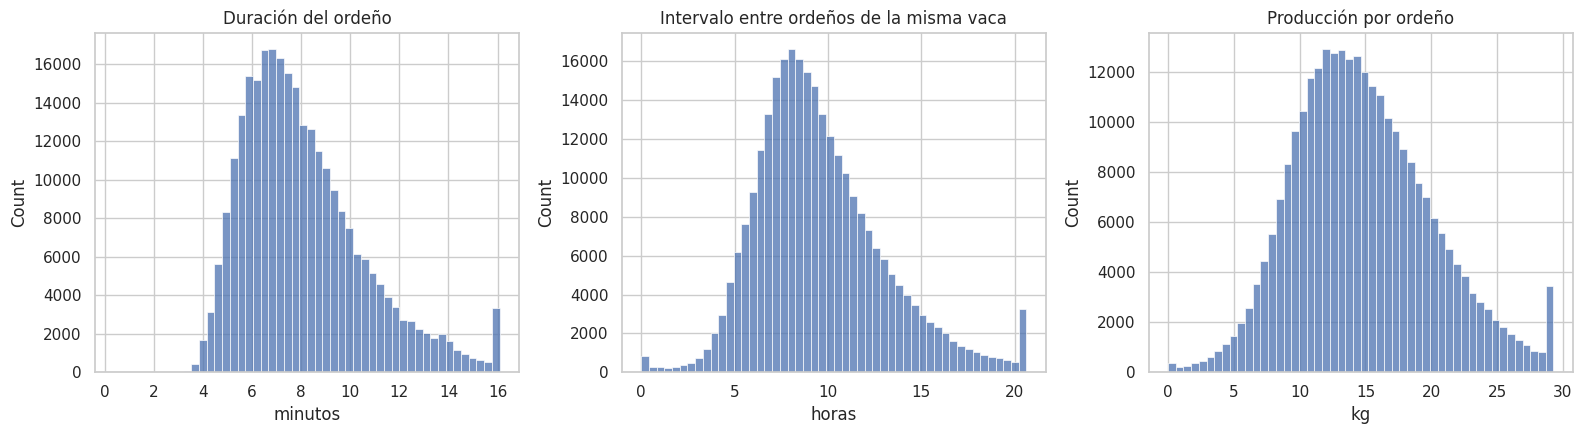

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(df["duracion_min"].clip(upper=df["duracion_min"].quantile(.99)), bins=50, ax=axes[0])
axes[0].set(title="Duración del ordeño", xlabel="minutos")
sns.histplot(df["intervalo_min"].clip(upper=df["intervalo_min"].quantile(.99)) / 60, bins=50, ax=axes[1])
axes[1].set(title="Intervalo entre ordeños de la misma vaca", xlabel="horas")
sns.histplot(df["Producción (kg)"].clip(upper=df["Producción (kg)"].quantile(.99)), bins=50, ax=axes[2])
axes[2].set(title="Producción por ordeño", xlabel="kg")
plt.tight_layout(); plt.show()

## 13. Ocupacion de cada robot por hora

Calculamos que porcentaje de cada hora estuvo ocupado por cada robot, sumando la duracion de los ordeños que empezaron en esa hora

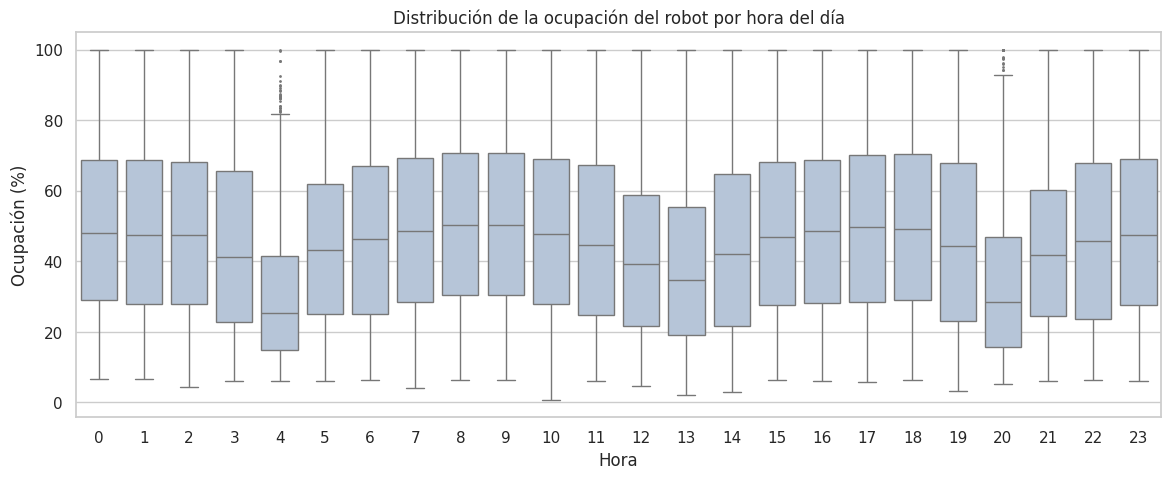

In [36]:
# Minutos de ordeño por robot, fecha y hora
ocup = (df.dropna(subset=["Hora de inicio", "MS", "duracion_min"])
          .groupby(["MS", "fecha", "hora"])["duracion_min"].sum()
          .reset_index())
ocup["ocupacion_pct"] = (ocup["duracion_min"] / 60 * 100).clip(upper=100)
ocup["dia_semana"] = pd.to_datetime(ocup["fecha"]).dt.dayofweek

plt.figure(figsize=(14, 5))
sns.boxplot(data=ocup, x="hora", y="ocupacion_pct", color="lightsteelblue", fliersize=1)
plt.title("Distribución de la ocupación del robot por hora del día")
plt.ylabel("Ocupación (%)"); plt.xlabel("Hora"); plt.show()

Ocupacion media del robot para cada combinacion de dia de la semana y hora

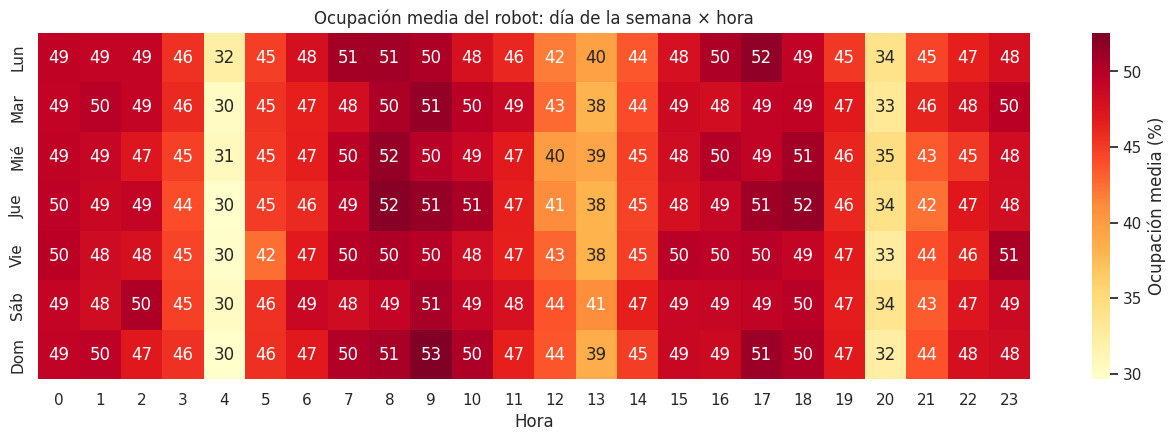

In [37]:
mapa = ocup.pivot_table(index="dia_semana", columns="hora", values="ocupacion_pct", aggfunc="mean")
mapa.index = [dias[i] for i in mapa.index]

plt.figure(figsize=(16, 4.5))
sns.heatmap(mapa, cmap="YlOrRd", annot=True, fmt=".0f", cbar_kws={"label": "Ocupación media (%)"})
plt.title("Ocupación media del robot: día de la semana × hora"); plt.xlabel("Hora"); plt.ylabel("")
plt.show()

In [38]:
# Ocupación media por robot (para ver si algún robot está más saturado que otros)
ocup.groupby("MS")["ocupacion_pct"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
MS,,,,,,,,
VMS 1,27032.0,49.1,24.8,3.9,28.4,48.0,68.2,100.0
VMS 2,26912.0,45.5,25.5,3.3,23.0,43.0,66.5,100.0
VMS 3,27069.0,44.7,24.3,0.8,24.2,42.0,63.2,100.0


## 14. Tiempo libre entre ordeños
Para cada robot se calcula el tiempo libre entre el fin de un ordeño y el incio del siguiente. En el caso de que tenga un valor de 2 minutos o menos, sera marcadabo como posible cola, debido a que lo mas probable es que la siguiente vaca este esperando

In [39]:
UMBRAL_COLA_MIN = 2   # ajustable: ≤ 2 min libres entre ordeños se considera "posible cola"

s = df.dropna(subset=["Hora de inicio", "MS", "duracion_min"]).sort_values(["MS", "Hora de inicio"]).copy()
s["fin"] = s["Hora de inicio"] + pd.to_timedelta(s["duracion_min"], unit="m")
s["siguiente_inicio"] = s.groupby("MS")["Hora de inicio"].shift(-1)
s["tiempo_libre_min"] = (s["siguiente_inicio"] - s["fin"]).dt.total_seconds() / 60

# Valores negativos = traslapes (posibles errores de registro o duplicados)
print(f"Traslapes (tiempo libre < 0): {(s['tiempo_libre_min'] < 0).sum():,}")
s = s[s["tiempo_libre_min"].between(0, 24 * 60)]
s["posible_cola"] = s["tiempo_libre_min"] <= UMBRAL_COLA_MIN

print(f"Ordeños seguidos de otro en ≤ {UMBRAL_COLA_MIN} min: {s['posible_cola'].mean():.1%}")
s["tiempo_libre_min"].describe(percentiles=[.1, .25, .5, .75, .9]).round(2)

Traslapes (tiempo libre < 0): 2
Ordeños seguidos de otro en ≤ 2 min: 53.7%


,tiempo_libre_min
count,278961.00
mean,11.96
std,25.62
min,0.10
10%,0.38
25%,0.48
50%,1.22
75%,12.12
90%,34.02
max,709.03


El histograma muestra como se distribuye el tiempo libre entre ordeños junto con el umbral elegido, por el contrario la grafica de barras indica que horas del dia es mas frecuente que haya cola.

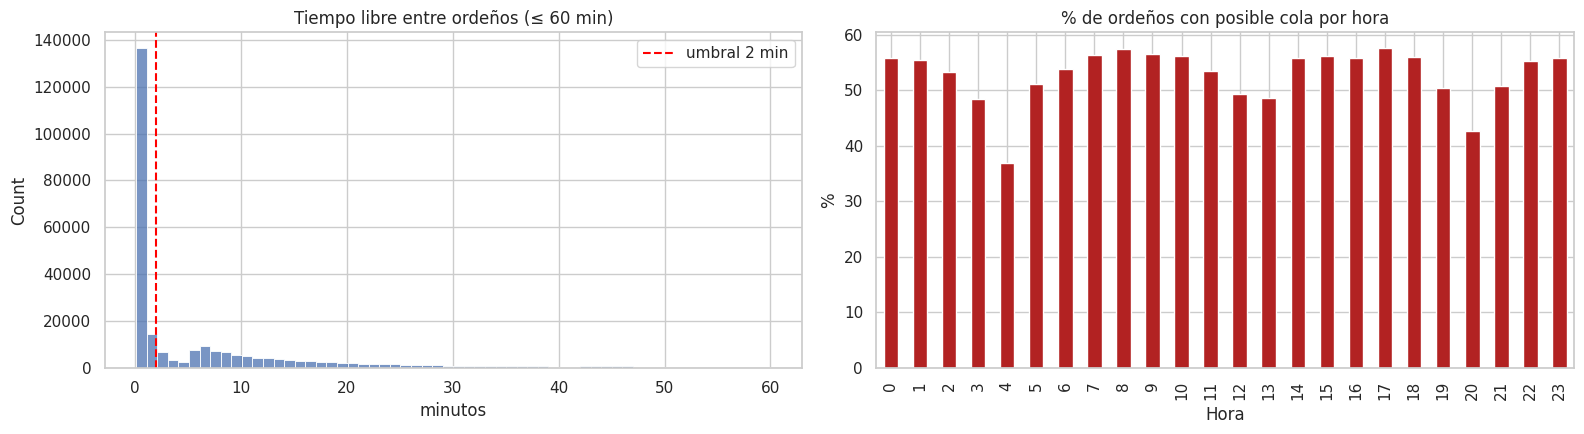

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
sns.histplot(s.loc[s["tiempo_libre_min"] <= 60, "tiempo_libre_min"], bins=60, ax=axes[0])
axes[0].axvline(UMBRAL_COLA_MIN, color="red", ls="--", label=f"umbral {UMBRAL_COLA_MIN} min")
axes[0].set(title="Tiempo libre entre ordeños (≤ 60 min)", xlabel="minutos"); axes[0].legend()

(s.groupby("hora")["posible_cola"].mean() * 100).plot.bar(ax=axes[1], color="firebrick")
axes[1].set(title="% de ordeños con posible cola por hora", xlabel="Hora", ylabel="%")
plt.tight_layout(); plt.show()

Mostramos el porcentaje de ordeños con posible cola para cada combinación de día de la semana y hora, para ubicar los momentos más críticos.

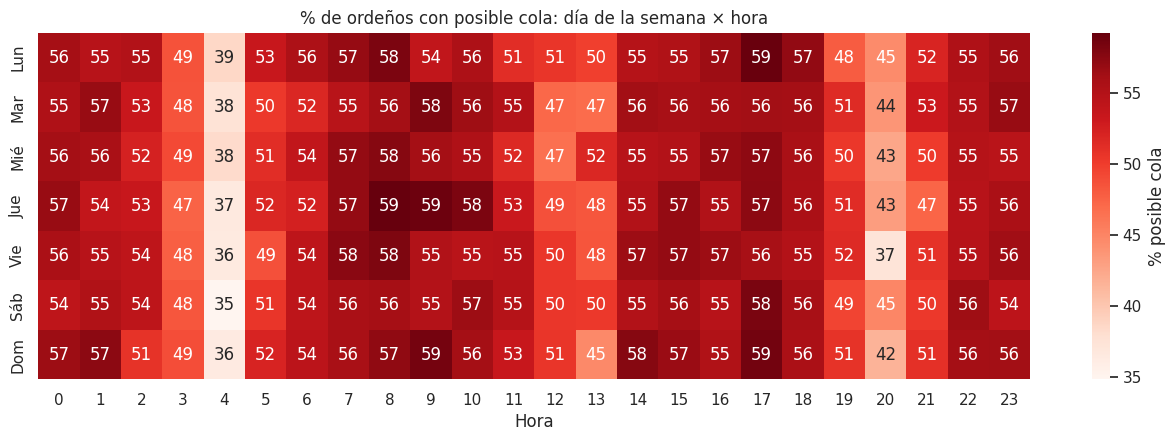

In [41]:
mapa_cola = s.pivot_table(index="dia_semana", columns="hora", values="posible_cola", aggfunc="mean") * 100
mapa_cola.index = [dias[i] for i in mapa_cola.index]

plt.figure(figsize=(16, 4.5))
sns.heatmap(mapa_cola, cmap="Reds", annot=True, fmt=".0f", cbar_kws={"label": "% posible cola"})
plt.title("% de ordeños con posible cola: día de la semana × hora"); plt.xlabel("Hora"); plt.ylabel("")
plt.show()

## 15. Condiciones operativas asociadas a la posible cola

Convertimos las incidencias del ordeno en variables binarias y comparamos sus promedios, junto con la duracion, intervalo y produccion entre los ordenos que fueron seguidos de una posible cola y los que no.

In [42]:
# Incidencias del ordeño como variables binarias
for col in ["Patada", "Incompleto", "Pezones no encontrados"]:
    if col in s.columns:
        s[f"tiene_{col}"] = s[col].notna()

comparar = ["duracion_min", "intervalo_min", "Producción (kg)",
            "tiene_Patada", "tiene_Incompleto", "tiene_Pezones no encontrados"]
comparar = [c for c in comparar if c in s.columns]

print("Promedios según si hubo posible cola después del ordeño:")
s.groupby("posible_cola")[comparar].mean().T.round(3)

Promedios según si hubo posible cola después del ordeño:


posible_cola,False,True
duracion_min,8.072,8.121
intervalo_min,574.286,574.224
Producción (kg),14.391,15.193
tiene_Patada,0.167,0.155
tiene_Incompleto,0.143,0.100
tiene_Pezones no encontrados,0.138,0.101


Correlacion entre variables numericas y el indicador de posible cola para identificar cuales se relacionan mas con la formacion de colas.

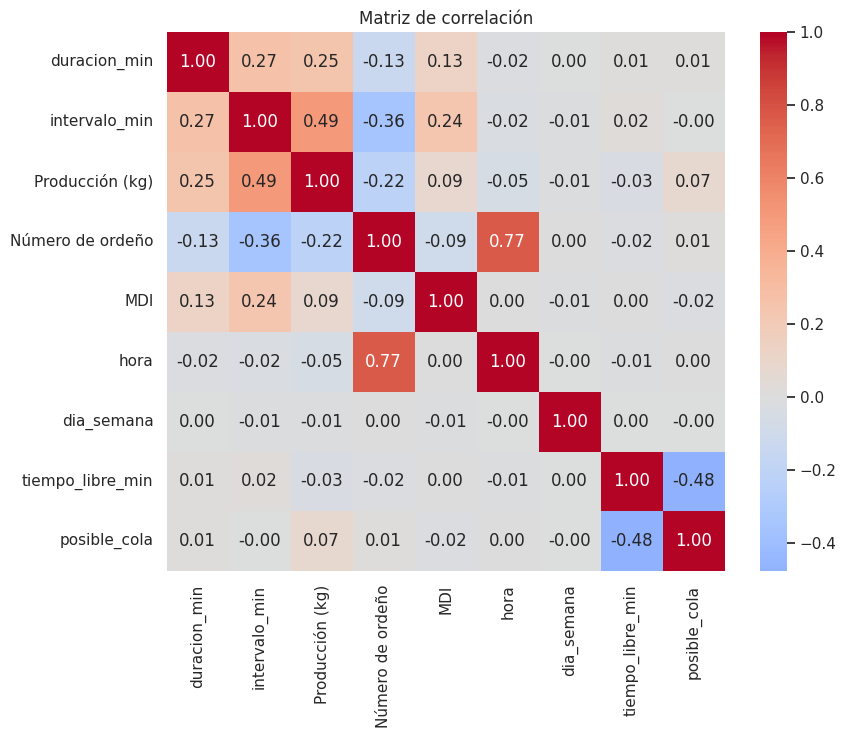

In [43]:
# Correlación entre variables numéricas y los indicadores de cola
num = ["duracion_min", "intervalo_min", "Producción (kg)", "Número de ordeño", "MDI",
       "hora", "dia_semana", "tiempo_libre_min", "posible_cola"]
num = [c for c in num if c in s.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(s[num].astype(float).corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación"); plt.show()

Se cuentan que vacas entran al robot con mas frecuencia justo despues de otro ordeno, en otras palabras son las que mas probablemente estuvieron en la fila.

In [44]:
# Vacas que con más frecuencia entran justo después de otra (posible espera en cola)
por_vaca = (s.assign(siguiente_vaca=s.groupby("MS")["ID_Vaca"].shift(-1))
              .loc[lambda d: d["posible_cola"]]
              .groupby("siguiente_vaca").size()
              .sort_values(ascending=False))
print("Top 10 vacas que entran con ≤ 2 min de espacio tras otro ordeño:")
por_vaca.head(10).to_frame("veces")

Top 10 vacas que entran con ≤ 2 min de espacio tras otro ordeño:


,veces
siguiente_vaca,
1557,1511
6208,1482
6122,1441
6119,1435
6036,1411
6181,1406
6161,1389
1623,1387
1555,1381
